# End-to-End Convolutional Neural Network for the Detection of Humans in Fire with a Flask Web Application

# Import and Set Dataset Path

In [3]:
# -------------------------------
# Define dataset path
# -------------------------------

import os
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import random
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

data_dir = r"C:\Users\nitin\OneDrive\Desktop\fire_dataset" # change this to your dataset folder path

# Create training and validation datasets

In [4]:
# -------------------------------
# Create training and validation datasets
# -------------------------------
# We'll use 70% train, 20% validation, 10% test

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,       # 30% for val + test
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.


# Split datset into validation (20%) and test (10%)

In [5]:
# -------------------------------
# Split dataset into validation (20%) and test (10%)
# -------------------------------
val_size = 0.67  # 20% out of the 30% for validation
val_ds = val_test_ds.take(int(len(val_test_ds) * val_size))
test_ds = val_test_ds.skip(int(len(val_test_ds) * val_size))

# Check class names and dataset info

In [6]:
# -------------------------------
# Check class names and dataset info
# -------------------------------
class_names = train_ds.class_names  # Save before prefetching

print("Class names:", class_names)
print("Number of training batches:", len(train_ds))
print("Number of validation batches:", len(val_ds))
print("Number of test batches:", len(test_ds))

Class names: ['fire_images', 'non_fire_images']
Number of training batches: 22
Number of validation batches: 6
Number of test batches: 4


# Display training data

C:\Users\nitin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


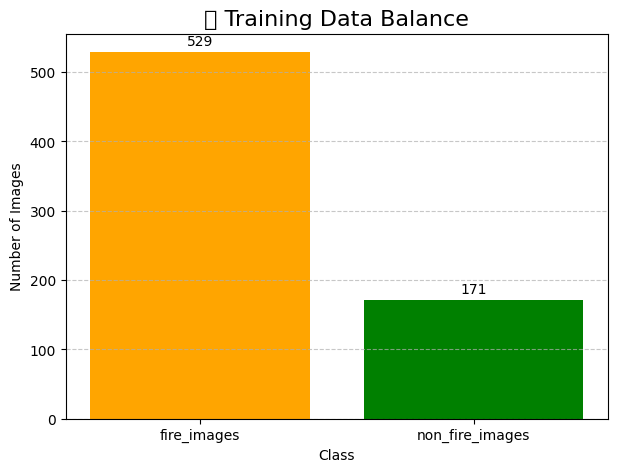

In [7]:
# Assuming you created the dataset like this:
# train_ds = tf.keras.utils.image_dataset_from_directory(
#     train_dir,
#     image_size=(224, 224),
#     batch_size=32
# )

# Get class names
class_names = train_ds.class_names

# Count samples per class
count_dict = {class_name: 0 for class_name in class_names}

for _, labels in train_ds.unbatch():
    label_idx = labels.numpy()
    class_name = class_names[label_idx]
    count_dict[class_name] += 1

# Prepare data for plotting
classes = list(count_dict.keys())
counts = list(count_dict.values())

# Plot
plt.figure(figsize=(7, 5))
bars = plt.bar(classes, counts, color=['orange', 'green'])
plt.title("🔥 Training Data Balance", fontsize=16)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontsize=10)

plt.show()

# Function to count samples per class

C:\Users\nitin\AppData\Local\Temp\ipykernel_20616\2318409100.py:44: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nitin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


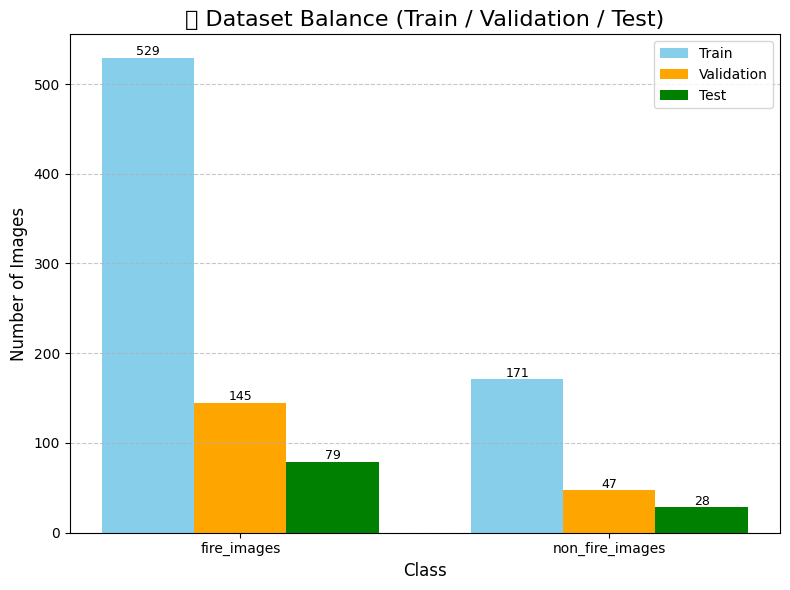

In [8]:
# Function to count samples per class
def count_classes(dataset, class_names):
    counts = {name: 0 for name in class_names}
    for _, label in dataset.unbatch():
        label_idx = label.numpy()
        counts[class_names[label_idx]] += 1
    return counts

# Get class names (from any split)
class_names = train_ds.class_names

# Count samples for each split
train_counts = count_classes(train_ds, class_names)
val_counts = count_classes(val_ds, class_names)
test_counts = count_classes(test_ds, class_names)

# Prepare data for plotting
x = np.arange(len(class_names))  # [0, 1, ...]
width = 0.25  # bar width

# Plot bars
plt.figure(figsize=(8, 6))
plt.bar(x - width, [train_counts[c] for c in class_names], width, label='Train', color='skyblue')
plt.bar(x, [val_counts[c] for c in class_names], width, label='Validation', color='orange')
plt.bar(x + width, [test_counts[c] for c in class_names], width, label='Test', color='green')

# Labels and aesthetics
plt.xlabel("Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("🔥 Dataset Balance (Train / Validation / Test)", fontsize=16)
plt.xticks(x, class_names)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on bars
def add_labels(bars, counts):
    for i, val in enumerate(counts):
        plt.text(bars[i], val + 3, str(val), ha='center', fontsize=9)

add_labels(x - width, [train_counts[c] for c in class_names])
add_labels(x, [val_counts[c] for c in class_names])
add_labels(x + width, [test_counts[c] for c in class_names])

plt.tight_layout()
plt.show()

# Visualize samples

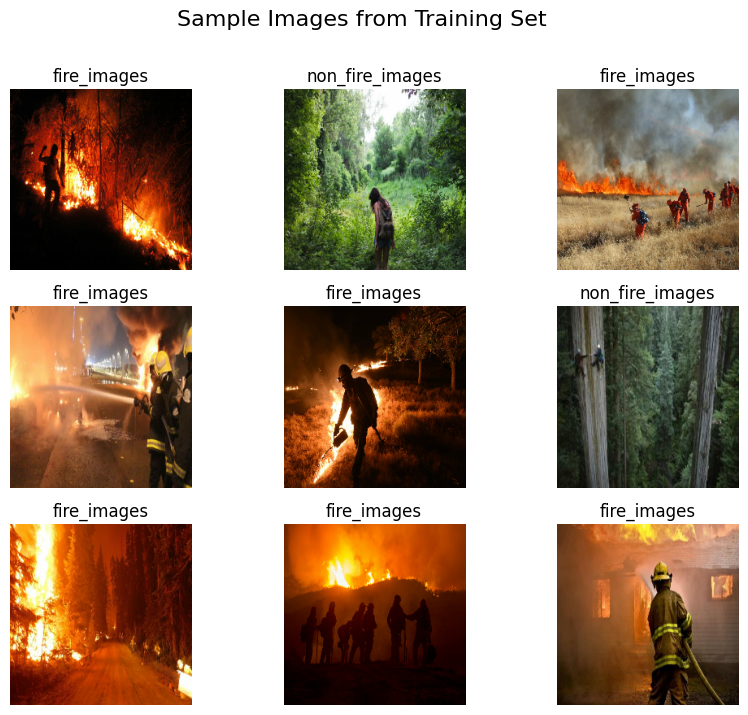

In [9]:
# -------------------------------
# Visualize samples
# -------------------------------
plt.figure(figsize=(10, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_name = train_ds.class_names[labels[i]]
        plt.title(label_name)
        plt.axis("off")
plt.suptitle("Sample Images from Training Set", fontsize=16)
plt.show()

# Normalize the images (0–1)

In [10]:
# -------------------------------
# Normalize the images (0–1)
# -------------------------------
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Build CNN model

In [11]:
# ------------------------------------------
# Build CNN model
# ------------------------------------------
model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.summary()

C:\Users\nitin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 614,929 (2.35 MB)

 Trainable params: 614,929 (2.35 MB)

 Non-trainable params: 0 (0.00 B)

# Compile the model

In [12]:
# ------------------------------------------
# Compile the model
# ------------------------------------------
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model

In [13]:
# ------------------------------------------
# Train the model
# ------------------------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 374ms/step - accuracy: 0.7386 - loss: 0.5445 - val_accuracy: 0.7448 - val_loss: 0.3186
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 413ms/step - accuracy: 0.8471 - loss: 0.2944 - val_accuracy: 0.9427 - val_loss: 0.2100
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 421ms/step - accuracy: 0.9200 - loss: 0.2249 - val_accuracy: 0.9583 - val_loss: 0.1423
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 408ms/step - accuracy: 0.9357 - loss: 0.1806 - val_accuracy: 0.9635 - val_loss: 0.1143
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 416ms/step - accuracy: 0.9600 - loss: 0.1070 - val_accuracy: 0.9792 - val_loss: 0.1041
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 421ms/step - accuracy: 0.9429 - loss: 0.1583 - val_accuracy: 0.9635 - val_loss: 0.1073
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 402ms/step - accuracy: 0.9614 - loss: 0.1540 - val_accuracy: 0.9167 - val_loss: 0.1752
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 405ms/step - accuracy: 0.9629 - loss: 0.0931 - val_accuracy: 

# Evaluate on test set

In [14]:
# ------------------------------------------
# Evaluate on test set
# ------------------------------------------
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9626 - loss: 0.0951

✅ Test Accuracy: 0.9626
✅ Test Loss: 0.0951


# Plot training results

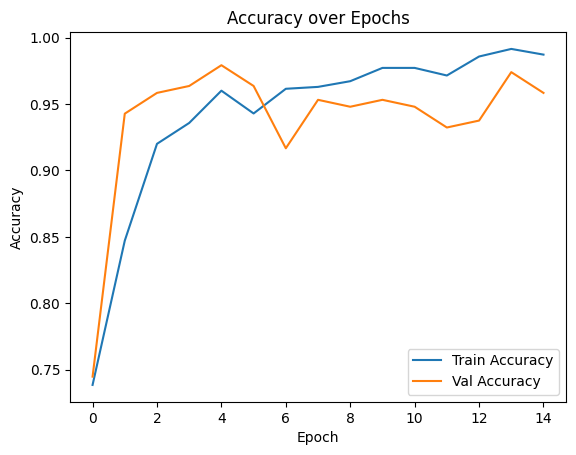

In [15]:
# ------------------------------------------
# Plot training results
# ------------------------------------------
#plt.figure(figsize=(14, 4))

plt.subplot(1, 1, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

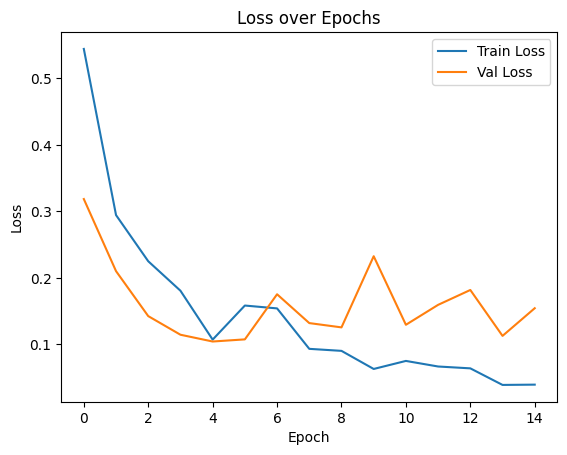

In [16]:
plt.subplot(1, 1, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Helper: Get predictions and true labels

In [17]:
# ------------------------------------------
# Helper: Get predictions and true labels
# ------------------------------------------
def get_predictions_and_labels(model, dataset):
    y_true = []
    y_pred = []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        preds = (preds > 0.5).astype("int32").flatten()  # Binary threshold
        y_pred.extend(preds)
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_pred)

# Evaluate on Train Set


🧩 Training Set Metrics:
                 precision    recall  f1-score   support

    fire_images       0.99      1.00      1.00       529
non_fire_images       0.99      0.98      0.99       171

       accuracy                           0.99       700
      macro avg       0.99      0.99      0.99       700
   weighted avg       0.99      0.99      0.99       700

F1-Score: 0.9882352941176471


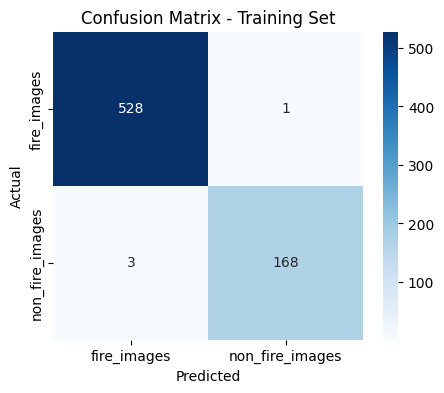

In [18]:
# ------------------------------------------
# Evaluate on Train Set
# ------------------------------------------
y_train_true, y_train_pred = get_predictions_and_labels(model, train_ds)
print("\n🧩 Training Set Metrics:")
print(classification_report(y_train_true, y_train_pred, target_names=class_names))
print("F1-Score:", f1_score(y_train_true, y_train_pred))

# Confusion matrix for train
cm_train = confusion_matrix(y_train_true, y_train_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Training Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Evaluate on Validation Set


🧩 Validation Set Metrics:
                 precision    recall  f1-score   support

    fire_images       0.96      0.97      0.97       148
non_fire_images       0.90      0.86      0.88        44

       accuracy                           0.95       192
      macro avg       0.93      0.92      0.93       192
   weighted avg       0.95      0.95      0.95       192

F1-Score: 0.8837209302325582


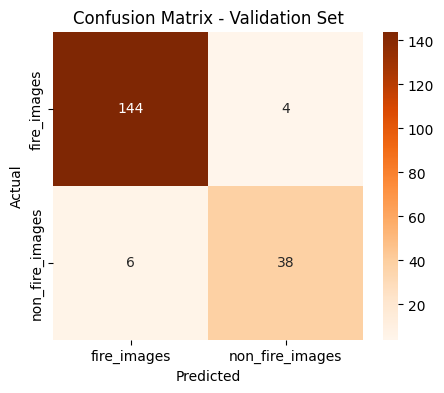

In [19]:
# ------------------------------------------
# Evaluate on Validation Set
# ------------------------------------------
y_val_true, y_val_pred = get_predictions_and_labels(model, val_ds)
print("\n🧩 Validation Set Metrics:")
print(classification_report(y_val_true, y_val_pred, target_names=class_names))
print("F1-Score:", f1_score(y_val_true, y_val_pred))

cm_val = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Validation Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Evaluate on Test Set


🧩 Test Set Metrics:
                 precision    recall  f1-score   support

    fire_images       0.94      1.00      0.97        74
non_fire_images       1.00      0.85      0.92        33

       accuracy                           0.95       107
      macro avg       0.97      0.92      0.94       107
   weighted avg       0.96      0.95      0.95       107

F1-Score: 0.9180327868852459


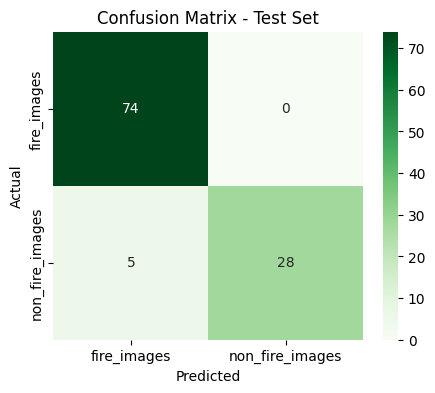

In [20]:
# ------------------------------------------
# Evaluate on Test Set
# ------------------------------------------
y_test_true, y_test_pred = get_predictions_and_labels(model, test_ds)
print("\n🧩 Test Set Metrics:")
print(classification_report(y_test_true, y_test_pred, target_names=class_names))
print("F1-Score:", f1_score(y_test_true, y_test_pred))

cm_test = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Fire Detection - 20 Random Test Predictions

C:\Users\nitin\AppData\Local\Temp\ipykernel_20616\4005874884.py:35: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nitin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


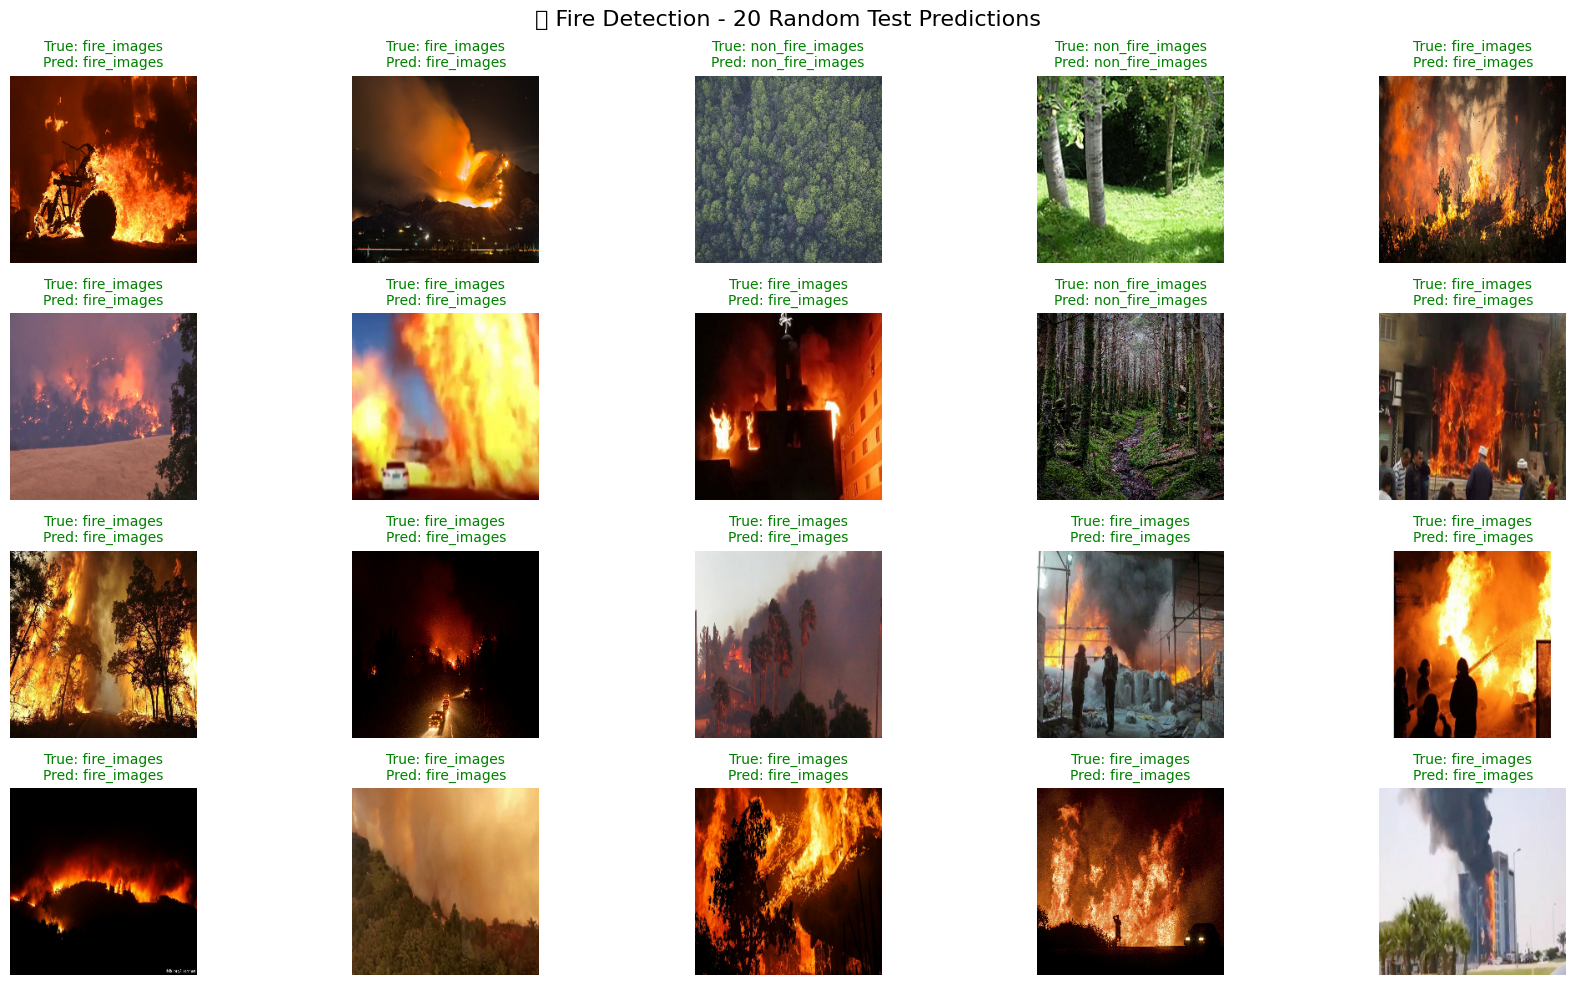

In [21]:
# Assume test_ds and class_names are already defined
images, labels = [], []
for img, label in test_ds.unbatch():
    images.append(img)
    labels.append(label.numpy())
images = np.array(images)
labels = np.array(labels)

random_indices = random.sample(range(len(images)), 20)

plt.figure(figsize=(18, 10))
for i, idx in enumerate(random_indices):
    img = images[idx]
    true_label = labels[idx]

    # Predict
    img_batch = tf.expand_dims(img, axis=0)
    pred = model.predict(img_batch, verbose=0)

    # Detect output type (sigmoid or softmax)
    if pred.shape[-1] == 1:   # sigmoid output
        pred_label = int(pred[0][0] > 0.5)
    else:                     # softmax output
        pred_label = np.argmax(pred, axis=1)[0]

    color = "green" if true_label == pred_label else "red"

    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}",
              color=color, fontsize=10)

plt.suptitle("🔥 Fire Detection - 20 Random Test Predictions", fontsize=16)
plt.tight_layout()
plt.show()

# Save model

In [22]:
model.save("models/fire_detection_model.h5")  # or .keras

# Fire / Non-Fire Classification and Human Detection from Images

In [23]:
# Full integrated pipeline: YOLO (person) + CNN (fire) with robust preprocessing selection,
# flame-color secondary check, and "annotate only when FIRE" behaviour.
# Adjust thresholds / FIRE_PREPROCESS if you want to force a preprocessing variant.

import os, glob, cv2, numpy as np, matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
MODELS_DIR = "models"
YOLO_CFG = os.path.join(MODELS_DIR, "yolov3.cfg")
YOLO_WEIGHTS = os.path.join(MODELS_DIR, "yolov3.weights")
COCO_NAMES = os.path.join(MODELS_DIR, "coco.names")
FIRE_MODEL_PATH = os.path.join(MODELS_DIR, "fire_detection_model.h5")

TEST_DIR = "test"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# YOLO params
YOLO_CONF_THRESHOLD = 0.5
YOLO_NMS_THRESHOLD = 0.4
YOLO_INPUT_SIZE = (416, 416)  # (width, height)

# Fire params and preprocessing selection:
# FIRE_PREPROCESS can be "auto" or one of: "rgb_0_1","rgb_-1_1","bgr_0_1","bgr_-1_1"
FIRE_PREPROCESS = "auto"
FIRE_CONF_THRESHOLD = 0.85   # CNN threshold to call FIRE
USE_FLAME_CHECK = True       # require color-based flame confirmation
MIN_FIRE_PIXEL_RATIO = 0.005 # fraction of image pixels that must be flame-like (0.5%)

# Optional: if your fire model uses a specific output index for 'fire', set it (None to auto-interpret)
FIRE_CLASS_INDEX = None

# ----------------- YOLO: load / detect / draw -----------------
def load_yolo(cfg_path=YOLO_CFG, weights_path=YOLO_WEIGHTS, names_path=COCO_NAMES):
    missing = [p for p in (cfg_path, weights_path, names_path) if not os.path.exists(p)]
    if missing:
        raise FileNotFoundError(f"Missing YOLO files: {missing}. Place them in '{MODELS_DIR}' or update paths.")
    net = cv2.dnn.readNet(weights_path, cfg_path)
    with open(names_path, "r") as f:
        classes = [c.strip() for c in f.readlines() if c.strip()]
    layer_names = net.getLayerNames()
    unconnected = net.getUnconnectedOutLayers()
    try:
        out_layers = [layer_names[i-1] for i in unconnected.flatten()]
    except Exception:
        out_layers = [layer_names[i-1] for i in unconnected]
    person_id = classes.index("person") if "person" in classes else 0
    print(f"YOLO loaded: #classes={len(classes)}, PERSON_CLASS_ID={person_id}, #output_layers={len(out_layers)}")
    return net, out_layers, person_id

def detect_persons(frame_bgr, net, out_layers, person_id, conf_threshold=YOLO_CONF_THRESHOLD, input_size=YOLO_INPUT_SIZE):
    h, w = frame_bgr.shape[:2]
    blob = cv2.dnn.blobFromImage(frame_bgr, 1/255.0, input_size, swapRB=True, crop=False)
    net.setInput(blob)
    outs = net.forward(out_layers)
    boxes, confs, cids = [], [], []
    for out in outs:
        for det in out:
            scores = det[5:]
            if scores.size == 0: 
                continue
            class_id = int(np.argmax(scores))
            score = float(scores[class_id])
            if class_id == person_id and score > conf_threshold:
                cx, cy, bw, bh = (det[0:4] * np.array([w, h, w, h])).astype(int)
                x = int(cx - bw/2); y = int(cy - bh/2)
                x, y = max(0, x), max(0, y)
                bw = min(w - x, int(bw)); bh = min(h - y, int(bh))
                boxes.append([x, y, int(bw), int(bh)]); confs.append(score); cids.append(class_id)
    final_boxes, final_confs = [], []
    if boxes:
        idxs = cv2.dnn.NMSBoxes(boxes, confs, conf_threshold, YOLO_NMS_THRESHOLD)
        if isinstance(idxs, (list, tuple, np.ndarray)) and len(idxs) > 0:
            idxs_flat = np.array(idxs).flatten()
            for i in idxs_flat:
                final_boxes.append(boxes[i]); final_confs.append(confs[i])
    return final_boxes, final_confs

def draw_person_boxes(frame_bgr, boxes, confidences, show_conf=True):
    out = frame_bgr.copy()
    for (box, conf) in zip(boxes, confidences):
        x, y, bw, bh = box
        cv2.rectangle(out, (x,y), (x+bw, y+bh), (0,255,0), 2)
        label = f"person: {conf:.2f}" if show_conf else "person"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(out, (x, y-th-6), (x+tw+6, y), (0,255,0), -1)
        cv2.putText(out, label, (x+3, y-4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1)
    return out

# ----------------- Fire model preprocessing / helpers -----------------
def preprocess_for_variant(img_bgr, variant, target_W, target_H):
    # variants: "rgb_0_1","rgb_-1_1","bgr_0_1","bgr_-1_1"
    if variant.startswith("rgb"):
        img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    else:
        img = img_bgr.copy()
    img_resized = cv2.resize(img, (target_W, target_H))
    arr = img_to_array(img_resized).astype("float32")
    if variant.endswith("_0_1"):
        arr = arr / 255.0
    elif variant.endswith("_-1_1"):
        arr = (arr / 127.5) - 1.0
    else:
        arr = arr / 255.0
    return arr

def get_fire_confidence_from_flat(flat, forced_index=None):
    flat = np.array(flat).reshape(-1)
    if flat.size == 0:
        return 0.0, None, flat
    if forced_index is not None:
        idx = int(forced_index)
        idx = max(0, min(idx, flat.size-1))
        return float(flat[idx]), idx, flat
    if flat.size == 1:
        return float(flat[0]), 0, flat
    if flat.size == 2:
        return float(flat[1]), 1, flat   # default heuristic: index 1 == fire
    idx = int(np.argmax(flat))
    return float(flat[idx]), idx, flat

def evaluate_preprocessing_variants_on_dataset(model, test_dir=TEST_DIR, variants=None, sample_limit=200):
    if variants is None:
        variants = ["rgb_0_1","rgb_-1_1","bgr_0_1","bgr_-1_1"]
    files = []
    for ext in ("*.jpg","*.jpeg","*.png","*.bmp"):
        files.extend(glob.glob(os.path.join(test_dir, ext)))
    files = sorted(files)[:sample_limit]
    if not files:
        return None
    mean_scores = {v: [] for v in variants}
    in_shape = model.input_shape
    if len(in_shape) == 4:
        _, H, W, C = in_shape
    elif len(in_shape) == 3:
        H, W, C = in_shape
    else:
        H, W, C = 224, 224, 3
    if H is None or W is None:
        H, W = 224, 224
    for fp in files:
        img = cv2.imread(fp)
        if img is None: 
            continue
        for v in variants:
            arr = preprocess_for_variant(img, v, W, H)
            batch = np.expand_dims(arr, 0) if len(model.input_shape) == 4 else arr
            preds = model.predict(batch)
            flat = np.array(preds).reshape(-1)
            fire_conf, used_idx, _ = get_fire_confidence_from_flat(flat, forced_index=FIRE_CLASS_INDEX)
            mean_scores[v].append(float(fire_conf))
    avg = {v: (np.mean(mean_scores[v]) if len(mean_scores[v])>0 else -1.0) for v in variants}
    return avg

# ----------------- Simple flame color check -----------------
FLAME_HSV_RANGES = [
    (0, 25, 120, 255, 120, 255),   # red-orange
    (25, 40, 120, 255, 120, 255),  # orange-yellow
]

def flame_pixel_ratio(img_bgr, hsv_ranges=FLAME_HSV_RANGES, small_size=(320,320)):
    small = cv2.resize(img_bgr, small_size)
    hsv = cv2.cvtColor(small, cv2.COLOR_BGR2HSV)
    mask_total = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for (hl, hh, sl, sh, vl, vh) in hsv_ranges:
        lower = np.array([hl, sl, vl], dtype=np.uint8)
        upper = np.array([hh, sh, vh], dtype=np.uint8)
        m = cv2.inRange(hsv, lower, upper)
        mask_total = cv2.bitwise_or(mask_total, m)
    flame_pixels = int(np.count_nonzero(mask_total))
    total_pixels = mask_total.size
    return flame_pixels / float(total_pixels)

# ----------------- Load models once -----------------
net, output_layers, PERSON_CLASS_ID = load_yolo()

if not os.path.exists(FIRE_MODEL_PATH):
    raise FileNotFoundError(f"Fire model not found at {FIRE_MODEL_PATH}")
print("Loading fire model:", FIRE_MODEL_PATH)
fire_model = load_model(FIRE_MODEL_PATH)
print("Fire model loaded. input_shape:", fire_model.input_shape)

# Auto-detect best preprocessing variant if requested
if FIRE_PREPROCESS == "auto":
    print("AUTO-detecting best preprocessing variant over dataset...")
    avg_scores = evaluate_preprocessing_variants_on_dataset(fire_model, TEST_DIR)
    if avg_scores is None:
        print("No test images found for auto-detect. Defaulting to 'rgb_0_1'.")
        chosen_variant = "rgb_0_1"
    else:
        for k,v in avg_scores.items():
            print(f" - {k}: mean_conf={v:.6f}")
        # choose highest mean_conf
        chosen_variant = max(avg_scores.items(), key=lambda x: x[1])[0]
        print("Auto-detect picked:", chosen_variant)
else:
    chosen_variant = FIRE_PREPROCESS
    print("Using FIRE_PREPROCESS variant:", chosen_variant)

# Ensure fire model input dims
in_shape = fire_model.input_shape
if len(in_shape) == 4:
    _, H_in, W_in, C_in = in_shape
elif len(in_shape) == 3:
    H_in, W_in, C_in = in_shape
else:
    H_in, W_in, C_in = 224, 224, 3
if H_in is None or W_in is None:
    H_in, W_in = 224, 224

# ----------------- Main loop: process test images -----------------
img_files = []
for ext in ("*.jpg","*.jpeg","*.png","*.bmp"):
    img_files.extend(glob.glob(os.path.join(TEST_DIR, ext)))
img_files = sorted(img_files)
if not img_files:
    print(f"No images found in '{TEST_DIR}'. Place test images and rerun.")
else:
    for img_path in img_files:
        filename = os.path.basename(img_path)
        frame_bgr = cv2.imread(img_path)
        if frame_bgr is None:
            print("Failed to read:", img_path); continue

        # 1) YOLO person detection on the untouched frame
        boxes, confs = detect_persons(frame_bgr, net, output_layers, PERSON_CLASS_ID)

        # 2) Prepare clean input for CNN (do not use drawn/annotated image)
        arr = preprocess_for_variant(frame_bgr, chosen_variant, W_in, H_in)
        batch = np.expand_dims(arr, 0) if len(fire_model.input_shape) == 4 else arr

        # 3) CNN prediction (consistent shapes to avoid retracing)
        preds = fire_model.predict(batch)
        fire_conf, used_idx, pred_flat = get_fire_confidence_from_flat(preds, forced_index=FIRE_CLASS_INDEX)

        # 4) Optional flame color verification
        flame_ratio = flame_pixel_ratio(frame_bgr) if USE_FLAME_CHECK else 1.0

        # 5) Combined decision
        is_fire = (fire_conf >= FIRE_CONF_THRESHOLD) and (flame_ratio >= MIN_FIRE_PIXEL_RATIO if USE_FLAME_CHECK else True)

        # 6) Logging and annotate-only-when-fire
        print(f"{filename} -> fire_conf={fire_conf:.4f} (used_idx={used_idx}) flame_ratio={flame_ratio:.4f} persons={len(boxes)} -> {'FIRE' if is_fire else 'NO FIRE'} [preprocess={chosen_variant}]")

        if is_fire:
            annotated = draw_person_boxes(frame_bgr, boxes, confs, show_conf=True)
            label = f"FIRE {fire_conf:.2f}"
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
            cv2.rectangle(annotated, (5,5), (10+tw, 12+th), (0,0,255), -1)
            cv2.putText(annotated, label, (10, 10 + th), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)
            if len(boxes) > 0:
                alert = "ALERT: FIRE + HUMAN(S) DETECTED -> HIGH RISK"
                (atw, ath), _ = cv2.getTextSize(alert, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                ih, iw = annotated.shape[:2]
                cv2.rectangle(annotated, (5, ih - (20 + ath)), (5 + atw + 10, ih - 5), (0,0,255), -1)
                cv2.putText(annotated, alert, (10, ih - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
            out_path = os.path.join(OUTPUT_DIR, f"annotated_{chosen_variant}_{filename}")
            cv2.imwrite(out_path, annotated)
            print("Annotated saved to:", out_path)
            # display inline
            annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(10,6)); plt.imshow(annotated_rgb); plt.axis("off"); plt.title(f"{filename} | FIRE {fire_conf:.3f} | persons:{len(boxes)}"); plt.show()
        else:
            # do not annotate; optionally save for review (disabled by default)
            pass

print("Processing complete.")

YOLO loaded: #classes=80, PERSON_CLASS_ID=0, #output_layers=3
Loading fire model: models\fire_detection_model.h5
Fire model loaded. input_shape: (None, 224, 224, 3)
AUTO-detecting best preprocessing variant over dataset...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
 - rgb_0_1: mean_conf=0.000000
 - rgb_-1_1: mean_conf=0.000000
 - bgr_0_1: mean_conf=0.483089
 - bgr_-1_1: mean_conf=0.000000
Auto-detect picked: bgr_0_1
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step
fire.33.png -> fire_conf=0.4831 (used_idx=0) flame_ratio=0.6018 persons=1 -> NO FIRE [preprocess=bgr_0_1]
Processing complete.


# Fire / Non-Fire Classification and Human Detection from Videos

In [ ]:
# ============================
# VIDEO-ONLY HUMAN + FIRE DETECTION
# ============================
import os, glob, cv2, time, numpy as np

# ----------------- CONFIG -----------------
MODELS_DIR = "models"
YOLO_CFG = os.path.join(MODELS_DIR, "yolov3.cfg")
YOLO_WEIGHTS = os.path.join(MODELS_DIR, "yolov3.weights")
COCO_NAMES = os.path.join(MODELS_DIR, "coco.names")
FIRE_MODEL_PATH = os.path.join(MODELS_DIR, "fire_detection_model.h5")

TEST_DIR = "test"

# YOLO settings
YOLO_INPUT_SIZE = (416, 416)
YOLO_CONF = 0.5
YOLO_NMS = 0.4

# Fire CNN settings
FIRE_PREPROCESS = "bgr_0_1"     # Best variant detected in your earlier tests
FIRE_CONF_THRESHOLD = 0.85
PROCESS_EVERY_N_FRAMES = 3

# ------------ FIRE PREPROCESS HELPER --------------
def preprocess_fire(img_bgr, variant, W, H):
    if variant.startswith("rgb"):
        img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    else:
        img = img_bgr.copy()

    img = cv2.resize(img, (W, H))
    arr = img_to_array(img).astype("float32")

    if variant.endswith("_0_1"):
        arr = arr / 255.0
    elif variant.endswith("_-1_1"):
        arr = (arr / 127.5) - 1.0

    return arr

def get_fire_conf(flat):
    flat = np.array(flat).reshape(-1)
    if flat.size == 1:
        return float(flat[0])
    elif flat.size == 2:
        return float(flat[1])
    return float(flat[np.argmax(flat)])

# ---------------- YOLO HELPERS ----------------
def load_yolo(cfg_path, weights_path, names_path):
    net = cv2.dnn.readNet(weights_path, cfg_path)
    with open(names_path, "r") as f:
        classes = [c.strip() for c in f.readlines()]

    layer_names = net.getLayerNames()
    try:
        out_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers().flatten()]
    except:
        out_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]

    person_id = classes.index("person") if "person" in classes else 0
    return net, out_layers, person_id

def detect_persons(frame, net, out_layers, pid):
    h, w = frame.shape[:2]
    blob = cv2.dnn.blobFromImage(frame, 1/255.0, YOLO_INPUT_SIZE, swapRB=True, crop=False)
    net.setInput(blob)
    outs = net.forward(out_layers)

    boxes, confs = [], []
    for out in outs:
        for det in out:
            scores = det[5:]
            cid = int(np.argmax(scores))
            score = float(scores[cid])

            if cid == pid and score > YOLO_CONF:
                cx,cy,bw,bh = (det[0:4]*np.array([w,h,w,h])).astype(int)
                x = max(0, int(cx - bw/2))
                y = max(0, int(cy - bh/2))
                boxes.append([x,y,bw,bh])
                confs.append(score)

    # NMS
    final_boxes, final_scores = [], []
    if boxes:
        idxs = cv2.dnn.NMSBoxes(boxes, confs, YOLO_CONF, YOLO_NMS)
        if len(idxs) > 0:
            for i in idxs.flatten():
                final_boxes.append(boxes[i])
                final_scores.append(confs[i])

    return final_boxes, final_scores

def draw_humans(frame, boxes, confs):
    for (box, score) in zip(boxes, confs):
        x,y,w,h = box
        cv2.rectangle(frame, (x,y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(frame, f"person {score:.2f}", (x, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1)

# ---------------- Load Models ----------------
net, out_layers, PERSON_ID = load_yolo(YOLO_CFG, YOLO_WEIGHTS, COCO_NAMES)
fire_model = load_model(FIRE_MODEL_PATH)
print("Models loaded.")

# fire model input shape
_, H_in, W_in, _ = fire_model.input_shape

# ---------------- SELECT VIDEO FROM TEST FOLDER ----------------
video_files = []
for ext in ("*.mp4","*.avi","*.mov","*.mkv"):
    video_files.extend(glob.glob(os.path.join(TEST_DIR, ext)))

if not video_files:
    raise FileNotFoundError("❌ No video found in 'test/' folder. Please put a video inside.")

VIDEO_PATH = video_files[0]
print("Using video:", VIDEO_PATH)

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open video: {VIDEO_PATH}")

# --------------- REAL-TIME LOOP ---------------
frame_no = 0
print("Press Q to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_no += 1

    # YOLO always runs
    boxes, confs = detect_persons(frame, net, out_layers, PERSON_ID)
    draw_humans(frame, boxes, confs)

    # Fire detection every N frames
    if frame_no % PROCESS_EVERY_N_FRAMES == 0:
        arr = preprocess_fire(frame, FIRE_PREPROCESS, W_in, H_in)
        preds = fire_model.predict(np.expand_dims(arr, 0))
        fire_conf = get_fire_conf(preds)
        is_fire = fire_conf >= FIRE_CONF_THRESHOLD
    else:
        is_fire = False

    # Annotate FIRE
    if is_fire:
        cv2.putText(frame, f"FIRE {fire_conf:.2f}", (20,40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0,0,255), 3)

    # SHOW REALTIME
    cv2.imshow("Realtime Fire + Human Detection (Video Only)", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

print("Detection stopped.")

Models loaded.
Using video: test\fire-video.mp4
Press Q to quit.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1